# Quadriga — Rice Leaf Blast Detection (VGG16) Notebook

It is organised into the modules in the outline: **Pre-processing**, **EDA**, **Dataset Splitting**, **Training (VGG16 baseline)**, **Feature Extraction for PLSR/XGBoost**, **Validation**, **Testing**, and **Reporting**.

# Library and Initializaations

In [40]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageFilter
import hashlib
import shutil
import time
import joblib

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# XGBoost (if available)
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not installed. PLSR will be used as alternative.")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set paths to datasets
DATA_DIR_BANGLADESH = "E:/Codes/Jupytr/datasets/RiceLeaf/GlobalRiceLeaf/BangladeshiCrops/BangladeshiCrops/Crop___Disease/Rice"
DATA_DIR_PH = "E:/Codes/Jupytr/datasets/RiceLeaf/LocalRiceLeaf/resized_raw_images/resized_raw_images"
OUTPUT_BASE = "E:/Codes/Jupytr/output/Output_Base"

# Create output directory
os.makedirs(OUTPUT_BASE, exist_ok=True)

# Configuration
IMG_EXTS = ('.jpg', '.jpeg', '.png')
TARGET_SIZE = (224, 224)  # VGG16 input size
BATCH_SIZE = 32
EPOCHS = 20

# Verify GPU Usage

In [41]:
import tensorflow as tf

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {gpus}")
    # Test GPU operation
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[1.0, 1.0], [0.0, 1.0]])
        c = tf.matmul(a, b)
        print("GPU matrix multiplication test passed!")
        print(c.numpy())
else:
    print("No GPU detected")

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU matrix multiplication test passed!
[[1. 3.]
 [3. 7.]]


## 1) Pre-processing Module

Steps:

1. Extract RGB images (PNG/JPG) into numpy arrays.
2. Remove duplicates and blurred images (manual or automatic). Placeholders included.
3. Annotate
4. Generate CSV or JSON with metadata and labels.

### 1.1 Image Extraction and Processing

In [42]:
def image_hash(path):
    """Calculate MD5 hash of an image file"""
    h = hashlib.md5()
    with open(path, 'rb') as f:
        h.update(f.read())
    return h.hexdigest()

def is_blurry(img, threshold=100.0):
    """Check if an image is blurry using variance of Laplacian"""
    try:
        # Convert to grayscale and calculate variance
        gray = img.convert('L')
        arr = np.array(gray).astype(np.float32)
        return arr.var() < threshold
    except:
        return True

def load_and_resize(path, target=TARGET_SIZE):
    """Load and resize an image"""
    img = Image.open(path).convert('RGB')
    img = img.resize(target, Image.BILINEAR)
    return img

def build_metadata(root_dir, origin_label='bangladesh'):
    """Build metadata dataframe for all images in directory"""
    meta = []
    root = Path(root_dir)
    
    for p in root.rglob('*'):
        if p.suffix.lower() in IMG_EXTS:
            try:
                img = Image.open(p)
                w, h = img.size
                hsh = image_hash(p)
                
                # Extract label from directory structure
                label = p.parent.name
                if origin_label == 'bangladesh':
                    if 'Healthy' in label:
                        label = 'healthy'
                    elif 'Blast' in label:
                        label = 'blast'
                    elif 'Brown' in label:
                        label = 'brown_spot'
                
                meta.append({
                    'filepath': str(p),
                    'filename': p.name,
                    'width': w,
                    'height': h,
                    'hash': hsh,
                    'origin': origin_label,
                    'label': label,
                    'keep': 1  # Assume valid initially
                })
            except Exception as e:
                print(f'Skipping {p}: {e}')
    
    return pd.DataFrame(meta)

# Build metadata for both datasets
print("Building metadata for Bangladeshi dataset...")
meta_b = build_metadata(DATA_DIR_BANGLADESH, 'bangladesh')

print("Building metadata for Philippine dataset...")
meta_ph = build_metadata(DATA_DIR_PH, 'philippines')

print(f'Bangladesh images found: {len(meta_b)}')
print(f'Philippines images found: {len(meta_ph)}')

# Merge metadata
raw_meta = pd.concat([meta_b, meta_ph], ignore_index=True)
raw_meta.to_csv(os.path.join(OUTPUT_BASE, 'raw_metadata.csv'), index=False)
print(f'Saved raw_metadata.csv to {OUTPUT_BASE}')

Building metadata for Bangladeshi dataset...
Building metadata for Philippine dataset...
Bangladesh images found: 1814
Philippines images found: 509
Saved raw_metadata.csv to E:/Codes/Jupytr/output/Output_Base


### 1.2 Duplicate and Blur Detection

In [43]:
# Detect duplicates
dupes = raw_meta[raw_meta.duplicated(subset=['hash'], keep=False)].copy() # hash refersh to the hash code in the metadata
print(f'Candidate duplicates: {len(dupes)}')

# Mark duplicates for removal
if len(dupes) > 0:
    # Keep first occurrence of each duplicate
    first_occurrences = dupes.drop_duplicates(subset=['hash'], keep='first').index
    raw_meta.loc[dupes.index.difference(first_occurrences), 'keep'] = 0

# Detect blurry images
blur_flags = []
for idx, row in raw_meta.iterrows():
    if row['keep'] == 1:  # Only check images not already marked for removal
        try:
            img = Image.open(row['filepath']).convert('RGB').resize(TARGET_SIZE)
            blur_flags.append(is_blurry(img, threshold=80.0))
        except Exception as e:
            blur_flags.append(True)
            print(f'Error reading {row["filepath"]}: {e}')
    else:
        blur_flags.append(False)  # Already marked for removal

raw_meta['is_blurry'] = blur_flags
raw_meta.loc[raw_meta['is_blurry'] == True, 'keep'] = 0

print(f'Blurry images found: {raw_meta["is_blurry"].sum()}')
print(f'Total images to keep: {raw_meta["keep"].sum()}')

# Save processed metadata
raw_meta.to_csv(os.path.join(OUTPUT_BASE, 'processed_metadata.csv'), index=False)

Candidate duplicates: 0
Blurry images found: 0
Total images to keep: 2323


### 1.3 Annotation cleansing

### 1.3 Generate CSV or JSON file of valid and invalid leaf images

### 1.3 Exploratory Data Analysis (EDA)

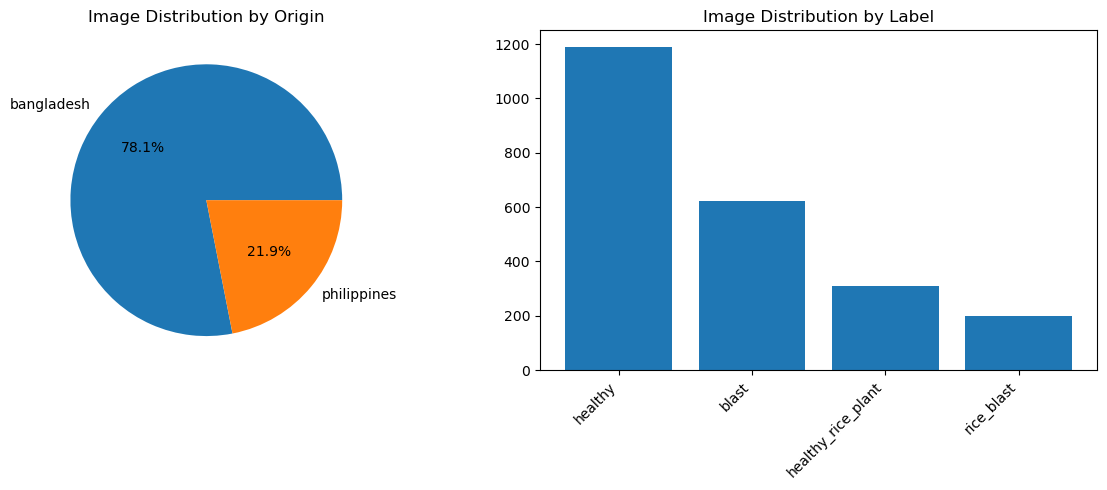

Class distribution:
label
healthy               1191
blast                  623
healthy_rice_plant     309
rice_blast             200
Name: count, dtype: int64


In [44]:
# Filter to only kept images
valid_meta = raw_meta[raw_meta['keep'] == 1].copy()

# Plot class distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
origin_counts = valid_meta['origin'].value_counts()
plt.pie(origin_counts.values, labels=origin_counts.index, autopct='%1.1f%%')
plt.title('Image Distribution by Origin')

plt.subplot(1, 2, 2)
label_counts = valid_meta['label'].value_counts()
plt.bar(range(len(label_counts)), label_counts.values)
plt.xticks(range(len(label_counts)), label_counts.index, rotation=45, ha='right')
plt.title('Image Distribution by Label')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'data_distribution.png'))
plt.show()

print("Class distribution:")
print(valid_meta['label'].value_counts())

### 1.4 Dataset Splitting

In [48]:
# --- Split datasets ---
bdf = valid_meta[valid_meta['origin'] == 'bangladesh'].copy()
phdf = valid_meta[valid_meta['origin'] == 'philippines'].copy()

# Keep only healthy & blast for Bangladesh dataset
bdf = bdf[bdf['label'].isin(['healthy', 'blast'])].copy()

# OPTIONAL: Normalize Philippine dataset labels to match Bangladesh
# If you want consistent labels for training, do this:
phdf['label'] = phdf['label'].replace({
    'healthy_rice_plant': 'healthy'
    # Add more mappings here if needed, e.g. 'blast_leaf': 'blast'
})

# Split Bangladeshi dataset into train (80%) and validation (20%)
from sklearn.model_selection import train_test_split
b_train, b_val = train_test_split(
    bdf, test_size=0.2, stratify=bdf['label'], random_state=42
)

print(f'Training images (Bangladesh): {len(b_train)}')
print(f'Validation images (Bangladesh): {len(b_val)}')
print(f'Testing images (Philippines): {len(phdf)}')

# --- Create directory structure dynamically ---
def create_dataset_structure(base_dir, labels):
    """Create train/val/test directories with class subfolders dynamically."""
    splits = ['train', 'val', 'test']
    for split in splits:
        for cls in labels:
            os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)
    return base_dir

# Get all unique class labels across train/val/test datasets
all_labels = sorted(pd.concat([b_train['label'], b_val['label'], phdf['label']]).unique())

dataset_dir = os.path.join(OUTPUT_BASE, 'organized_dataset')
create_dataset_structure(dataset_dir, all_labels)

# --- Copy images into organized dataset ---
def copy_images_to_structure(df, split_name):
    """Copy images to the organized dataset folder"""
    for idx, row in df.iterrows():
        try:
            img = load_and_resize(row['filepath'], TARGET_SIZE)
            dest_path = os.path.join(dataset_dir, split_name, row['label'], f"{row['hash']}.jpg")
            img.save(dest_path, format='JPEG', quality=90)
        except Exception as e:
            print(f"Error processing {row['filepath']}: {e}")

# Copy images
copy_images_to_structure(b_train, 'train')
copy_images_to_structure(b_val, 'val')
copy_images_to_structure(phdf, 'test')

print("✅ Dataset successfully organized!")

Training images (Bangladesh): 1451
Validation images (Bangladesh): 363
Testing images (Philippines): 509
✅ Dataset successfully organized!


### 1.5 Dataset Augmentation

In [59]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

# Validation and test data (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'val')
test_dir = os.path.join(dataset_dir, 'test')

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['healthy', 'blast'],
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['healthy', 'blast'],
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['healthy', 'rice_blast'],
    shuffle=False
)

# Get class indices
class_indices = train_generator.class_indices
print("Class indices:", class_indices)
NUM_CLASSES = len(class_indices)

Found 1451 images belonging to 2 classes.
Found 363 images belonging to 2 classes.
Found 509 images belonging to 2 classes.
Class indices: {'healthy': 0, 'blast': 1}


## 2. CNN Training Module

### 2.1 VGG16 Baseline Model

Model: "model_40"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0  

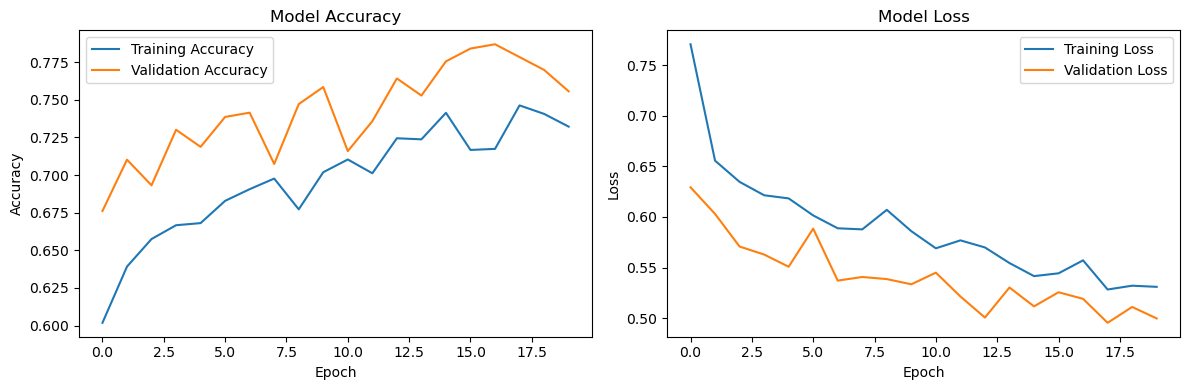

In [50]:
# Load pre-trained VGG16 without top layers
base_model = VGG16(
    weights='imagenet', 
    include_top=False, 
    input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 3)
)

# Freeze base model layers
base_model.trainable = False

# Add custom top layers
x = base_model.output
x = layers.Flatten()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)  # Binary classification

# Create model
model = models.Model(inputs=base_model.input, outputs=outputs)

# Compile model
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE
)

# Save the baseline model
model.save(os.path.join(OUTPUT_BASE, 'vgg16_baseline.h5'))
print('Baseline model saved!')

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'training_history.png'))
plt.show()

### 2.2 Feature Extraction for PLSR and XGBoost

In [51]:
# Create feature extractor from VGG16
feature_extractor = Model(
    inputs=base_model.input,
    outputs=base_model.get_layer('block5_pool').output
)

def extract_features(generator, feature_extractor):
    """Extract features from images using VGG16"""
    features = []
    labels = []
    
    for i in range(len(generator)):
        x, y = generator[i]
        features_batch = feature_extractor.predict(x, verbose=0)
        features.append(features_batch.reshape(x.shape[0], -1))
        labels.append(y)
    
    return np.vstack(features), np.hstack(labels)

# Extract features from training and validation sets
print("Extracting training features...")
X_train, y_train = extract_features(train_generator, feature_extractor)

print("Extracting validation features...")
X_val, y_val = extract_features(val_generator, feature_extractor)

print("Feature shapes:", X_train.shape, X_val.shape)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Save the scaler
joblib.dump(scaler, os.path.join(OUTPUT_BASE, 'feature_scaler.pkl'))

Extracting training features...
Extracting validation features...
Feature shapes: (1451, 25088) (363, 25088)


['E:/Codes/Jupytr/output/Output_Base\\feature_scaler.pkl']

### 2.3 PLSR with Thresholding

In [52]:
# Train PLSR model
pls = PLSRegression(n_components=10)
pls.fit(X_train_scaled, y_train)

# Predict on validation set
y_pred_pls = pls.predict(X_val_scaled).flatten()
y_pred_pls_binary = (y_pred_pls > 0.5).astype(int)

# Evaluate PLSR model
pls_accuracy = accuracy_score(y_val, y_pred_pls_binary)
pls_precision = precision_score(y_val, y_pred_pls_binary)
pls_recall = recall_score(y_val, y_pred_pls_binary)
pls_f1 = f1_score(y_val, y_pred_pls_binary)

print("PLSR Performance:")
print(f"Accuracy: {pls_accuracy:.4f}")
print(f"Precision: {pls_precision:.4f}")
print(f"Recall: {pls_recall:.4f}")
print(f"F1-Score: {pls_f1:.4f}")

# Save PLSR model
joblib.dump(pls, os.path.join(OUTPUT_BASE, 'pls_model.pkl'))

PLSR Performance:
Accuracy: 0.7273
Precision: 0.6327
Recall: 0.4960
F1-Score: 0.5561


['E:/Codes/Jupytr/output/Output_Base\\pls_model.pkl']

### 2.4 XGBoost Classifier

In [53]:
if XGB_AVAILABLE:
    # Train XGBoost classifier
    xgb_clf = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    xgb_clf.fit(X_train_scaled, y_train)
    
    # Predict on validation set
    y_pred_xgb = xgb_clf.predict(X_val_scaled)
    
    # Evaluate XGBoost model
    xgb_accuracy = accuracy_score(y_val, y_pred_xgb)
    xgb_precision = precision_score(y_val, y_pred_xgb)
    xgb_recall = recall_score(y_val, y_pred_xgb)
    xgb_f1 = f1_score(y_val, y_pred_xgb)
    
    print("XGBoost Performance:")
    print(f"Accuracy: {xgb_accuracy:.4f}")
    print(f"Precision: {xgb_precision:.4f}")
    print(f"Recall: {xgb_recall:.4f}")
    print(f"F1-Score: {xgb_f1:.4f}")
    
    # Save XGBoost model
    joblib.dump(xgb_clf, os.path.join(OUTPUT_BASE, 'xgb_model.pkl'))
else:
    print("XGBoost not available. Skipping XGBoost training.")

XGBoost Performance:
Accuracy: 0.7383
Precision: 0.7027
Recall: 0.4160
F1-Score: 0.5226


## 3. Validation Module

Evaluating baseline VGG16 model...
Evaluating PLSR model...
Evaluating XGBoost model...
Validation Results:
            Model  Accuracy  Precision  Recall  F1-Score  Inference Time (s)
0  VGG16 Baseline  0.749311   0.886364   0.312  0.461538            2.617525
1      VGG16+PLSR  0.727273   0.632653   0.496  0.556054            1.836446
2   VGG16+XGBoost  0.738292   0.702703   0.416  0.522613            1.863262


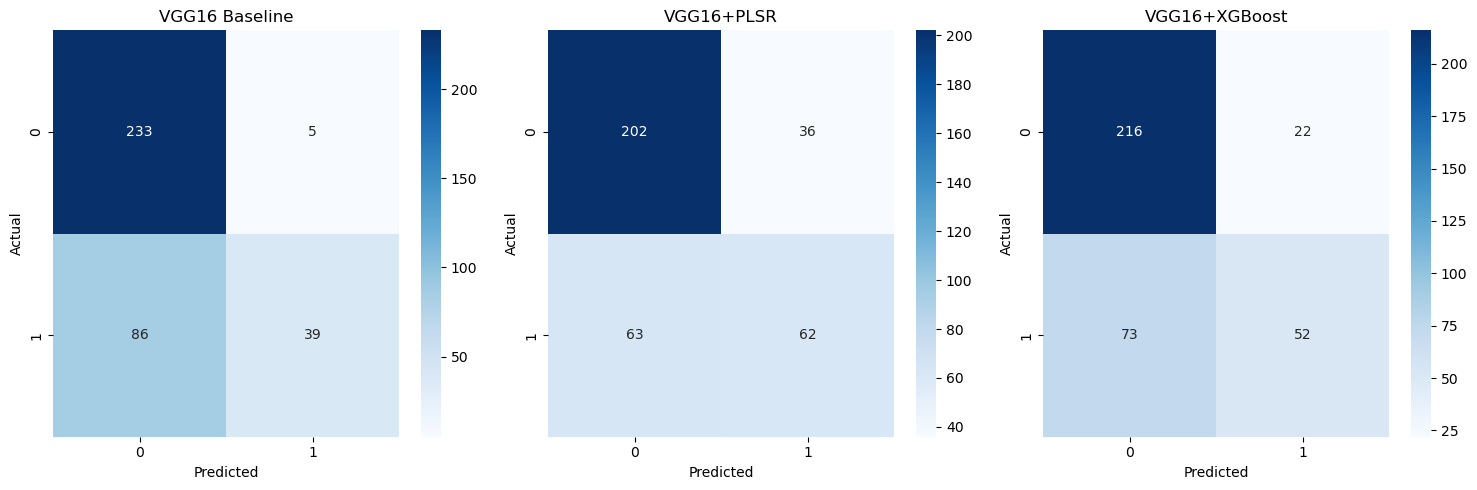

In [54]:
def evaluate_model(model, generator, model_type='keras'):
    """Evaluate a model on the validation set"""
    start_time = time.time()
    
    if model_type == 'keras':
        # For Keras models
        results = model.evaluate(generator, verbose=0)
        loss, accuracy = results[0], results[1]
        
        # Get predictions
        y_pred_proba = model.predict(generator, verbose=0)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()
        y_true = generator.classes
        
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        
    else:
        # For feature-based models (PLSR, XGBoost)
        # Extract features first
        X, y_true = extract_features(generator, feature_extractor)
        X_scaled = scaler.transform(X)
        
        if model_type == 'pls':
            y_pred_proba = model.predict(X_scaled).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)
        else:  # xgb
            y_pred = model.predict(X_scaled)
            y_pred_proba = model.predict_proba(X_scaled)[:, 1]
        
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        loss = None
    
    end_time = time.time()
    inference_time = end_time - start_time
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'loss': loss,
        'inference_time': inference_time,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

# Evaluate all models on validation set
print("Evaluating baseline VGG16 model...")
vgg16_results = evaluate_model(model, val_generator, 'keras')

print("Evaluating PLSR model...")
pls_results = evaluate_model(pls, val_generator, 'pls')

if XGB_AVAILABLE:
    print("Evaluating XGBoost model...")
    xgb_results = evaluate_model(xgb_clf, val_generator, 'xgb')

# Compare model performance
results_df = pd.DataFrame({
    'Model': ['VGG16 Baseline', 'VGG16+PLSR', 'VGG16+XGBoost'] if XGB_AVAILABLE else ['VGG16 Baseline', 'VGG16+PLSR'],
    'Accuracy': [vgg16_results['accuracy'], pls_results['accuracy'], xgb_results['accuracy']] if XGB_AVAILABLE else [vgg16_results['accuracy'], pls_results['accuracy']],
    'Precision': [vgg16_results['precision'], pls_results['precision'], xgb_results['precision']] if XGB_AVAILABLE else [vgg16_results['precision'], pls_results['precision']],
    'Recall': [vgg16_results['recall'], pls_results['recall'], xgb_results['recall']] if XGB_AVAILABLE else [vgg16_results['recall'], pls_results['recall']],
    'F1-Score': [vgg16_results['f1'], pls_results['f1'], xgb_results['f1']] if XGB_AVAILABLE else [vgg16_results['f1'], pls_results['f1']],
    'Inference Time (s)': [vgg16_results['inference_time'], pls_results['inference_time'], xgb_results['inference_time']] if XGB_AVAILABLE else [vgg16_results['inference_time'], pls_results['inference_time']]
})

print("Validation Results:")
print(results_df)

# Save validation results
results_df.to_csv(os.path.join(OUTPUT_BASE, 'validation_results.csv'), index=False)

# Plot confusion matrices
fig, axes = plt.subplots(1, 3 if XGB_AVAILABLE else 2, figsize=(15, 5))

# VGG16 Baseline
cm_vgg16 = confusion_matrix(vgg16_results['y_true'], vgg16_results['y_pred'])
sns.heatmap(cm_vgg16, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('VGG16 Baseline')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# PLSR
cm_pls = confusion_matrix(pls_results['y_true'], pls_results['y_pred'])
sns.heatmap(cm_pls, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('VGG16+PLSR')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# XGBoost
if XGB_AVAILABLE:
    cm_xgb = confusion_matrix(xgb_results['y_true'], xgb_results['y_pred'])
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[2])
    axes[2].set_title('VGG16+XGBoost')
    axes[2].set_xlabel('Predicted')
    axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'confusion_matrices.png'))
plt.show()

## 4. Explainability Analysis

Generating Grad-CAM visualizations...


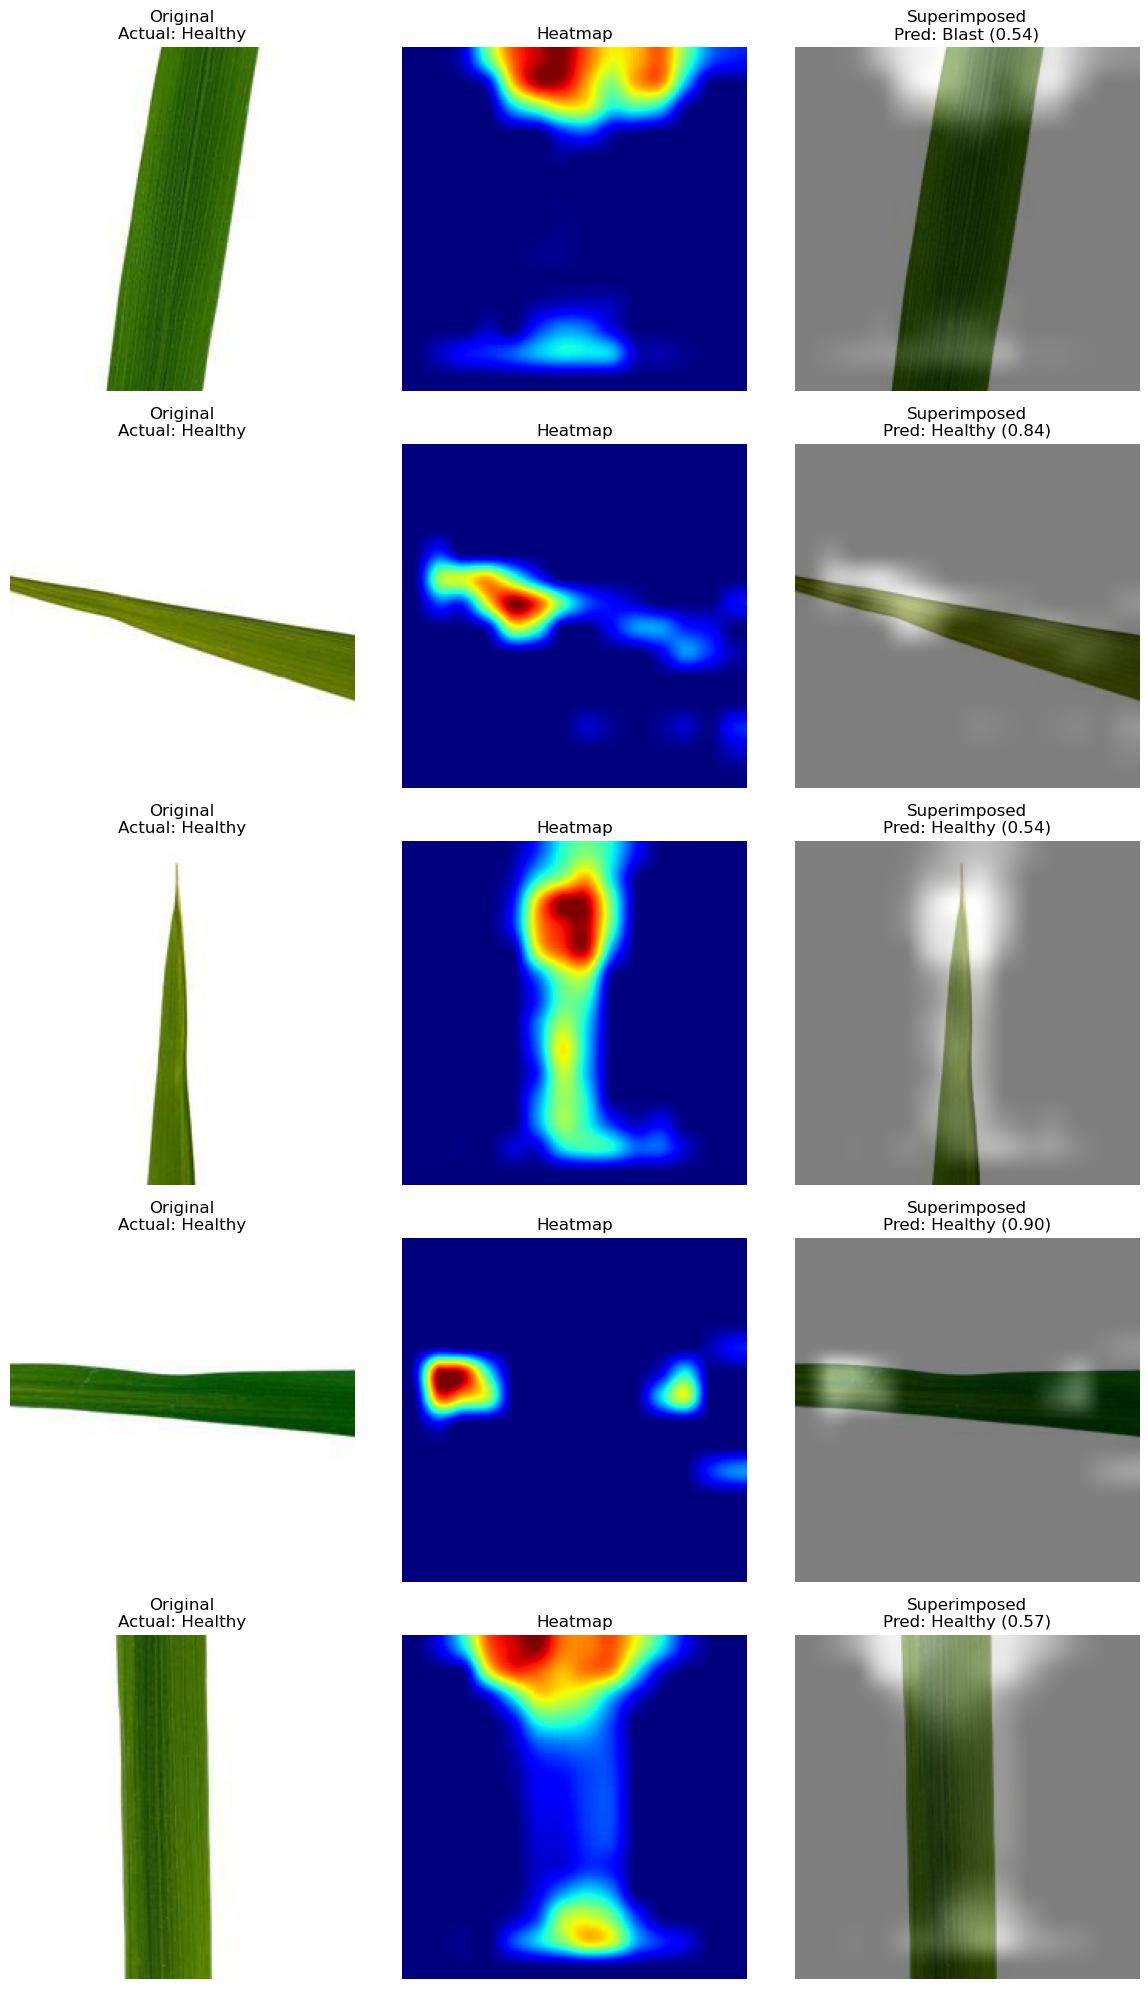

Notebook execution completed!


In [60]:
# Grad-CAM implementation for VGG16
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='block5_conv3'):
    """Generate Grad-CAM heatmap for a given image"""
    # Build a model that maps input -> (last conv layer outputs, predictions)
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    # Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        # For binary classification, use probability of class 1 ("blast")
        loss = predictions[:, 0]  

    # Get gradients of the predicted class wrt conv layer outputs
    grads = tape.gradient(loss, conv_outputs)
    
    # Compute mean intensity of gradients per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Weight conv layer outputs by channel importance
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    
    # Normalize heatmap (still a tensor)
    heatmap = tf.maximum(heatmap, 0)  # ReLU
    max_val = tf.reduce_max(heatmap)
    heatmap = heatmap / (max_val + 1e-8)

    return heatmap.numpy()  # Convert to numpy only at the end

# Apply Grad-CAM to sample images
def apply_gradcam_to_samples(generator, model, num_samples=5):
    """Apply Grad-CAM to sample images from generator"""
    # Get sample images
    x, y = generator[0]  # First batch
    samples = min(num_samples, x.shape[0])
    
    fig, axes = plt.subplots(samples, 3, figsize=(12, 4*samples))
    
    for i in range(samples):
        img_array = x[i:i+1]
        actual_label = "Blast" if y[i] == 1 else "Healthy"
        
        # Generate heatmap
        heatmap = make_gradcam_heatmap(img_array, model)
        
        # Resize heatmap to match original image
        heatmap = np.uint8(255 * heatmap)
        heatmap = Image.fromarray(heatmap).resize(TARGET_SIZE)
        heatmap = np.array(heatmap) / 255.0
        
        # Original image
        img = img_array[0]
        
        # Superimpose heatmap on original image
        superimposed_img = img * 0.5 + np.stack([heatmap]*3, axis=-1) * 0.5
        superimposed_img = np.clip(superimposed_img, 0, 1)
        
        # Get prediction
        pred = model.predict(img_array, verbose=0)[0][0]
        pred_label = "Blast" if pred > 0.5 else "Healthy"
        confidence = pred if pred > 0.5 else 1 - pred
        
        # Plot
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'Original\nActual: {actual_label}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(heatmap, cmap='jet')
        axes[i, 1].set_title('Heatmap')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(superimposed_img)
        axes[i, 2].set_title(f'Superimposed\nPred: {pred_label} ({confidence:.2f})')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_BASE, 'gradcam_examples.png'))
    plt.show()

# Apply Grad-CAM to sample images from test set
print("Generating Grad-CAM visualizations...")
apply_gradcam_to_samples(test_generator, model)

print("Notebook execution completed!")

## 5. Model Deployment Module

Testing on Philippine dataset...
Test Results (Philippine Dataset):
            Model  Accuracy  Precision  Recall  F1-Score  Inference Time (s)
0  VGG16 Baseline  0.719057   0.615385   0.760  0.680089            7.002786
1      VGG16+PLSR  0.601179   0.495413   0.810  0.614801            2.531994
2   VGG16+XGBoost  0.662083   0.725806   0.225  0.343511            2.531944


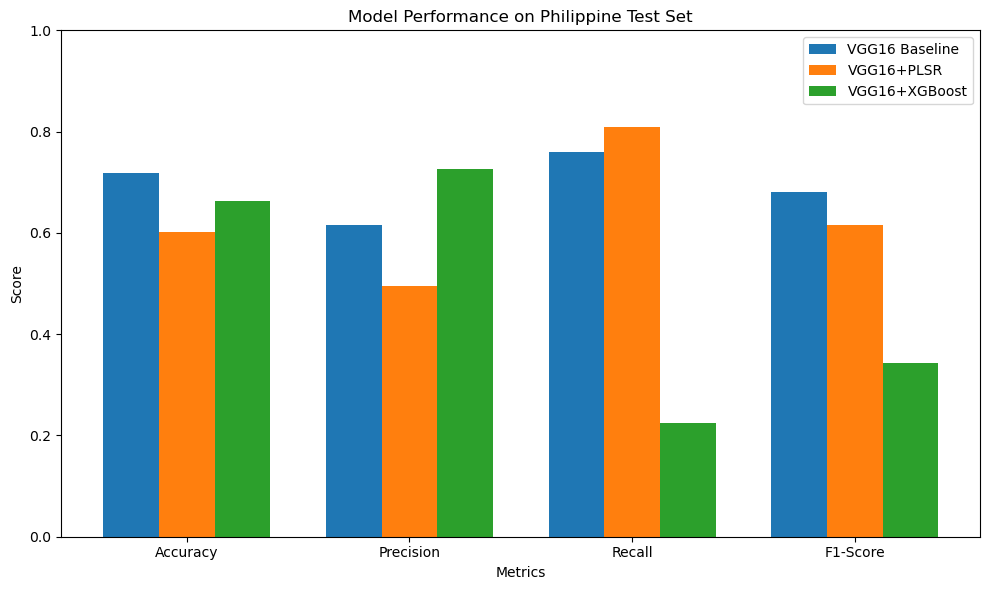

In [61]:
# Evaluate on Philippine test set
print("Testing on Philippine dataset...")

# Evaluate all models on test set
vgg16_test_results = evaluate_model(model, test_generator, 'keras')
pls_test_results = evaluate_model(pls, test_generator, 'pls')

if XGB_AVAILABLE:
    xgb_test_results = evaluate_model(xgb_clf, test_generator, 'xgb')

# Compare test performance
test_results_df = pd.DataFrame({
    'Model': ['VGG16 Baseline', 'VGG16+PLSR', 'VGG16+XGBoost'] if XGB_AVAILABLE else ['VGG16 Baseline', 'VGG16+PLSR'],
    'Accuracy': [vgg16_test_results['accuracy'], pls_test_results['accuracy'], xgb_test_results['accuracy']] if XGB_AVAILABLE else [vgg16_test_results['accuracy'], pls_test_results['accuracy']],
    'Precision': [vgg16_test_results['precision'], pls_test_results['precision'], xgb_test_results['precision']] if XGB_AVAILABLE else [vgg16_test_results['precision'], pls_test_results['precision']],
    'Recall': [vgg16_test_results['recall'], pls_test_results['recall'], xgb_test_results['recall']] if XGB_AVAILABLE else [vgg16_test_results['recall'], pls_test_results['recall']],
    'F1-Score': [vgg16_test_results['f1'], pls_test_results['f1'], xgb_test_results['f1']] if XGB_AVAILABLE else [vgg16_test_results['f1'], pls_test_results['f1']],
    'Inference Time (s)': [vgg16_test_results['inference_time'], pls_test_results['inference_time'], xgb_test_results['inference_time']] if XGB_AVAILABLE else [vgg16_test_results['inference_time'], pls_test_results['inference_time']]
})

print("Test Results (Philippine Dataset):")
print(test_results_df)

# Save test results
test_results_df.to_csv(os.path.join(OUTPUT_BASE, 'test_results.csv'), index=False)

# Plot test performance comparison
plt.figure(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

for i, model_name in enumerate(test_results_df['Model']):
    values = [
        test_results_df.loc[i, 'Accuracy'],
        test_results_df.loc[i, 'Precision'],
        test_results_df.loc[i, 'Recall'],
        test_results_df.loc[i, 'F1-Score']
    ]
    plt.bar(x + i*width, values, width, label=model_name)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance on Philippine Test Set')
plt.xticks(x + width, metrics)
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'test_performance.png'))
plt.show()

## 6. Reporting Module

In [62]:
# Create comprehensive report
report = {
    'Dataset Information': {
        'Bangladeshi Training Images': len(b_train),
        'Bangladeshi Validation Images': len(b_val),
        'Philippine Test Images': len(phdf),
        'Classes': list(class_indices.keys())
    },
    'Validation Performance': results_df.to_dict('records'),
    'Test Performance': test_results_df.to_dict('records'),
    'Best Model': None
}

# Identify best model based on F1-score
best_model_idx = test_results_df['F1-Score'].idxmax()
report['Best Model'] = test_results_df.loc[best_model_idx, 'Model']

print("="*50)
print("FINAL REPORT")
print("="*50)
print(f"Best Model: {report['Best Model']}")
print("\nValidation Performance:")
print(results_df)
print("\nTest Performance:")
print(test_results_df)

# Save full report
import json
with open(os.path.join(OUTPUT_BASE, 'full_report.json'), 'w') as f:
    json.dump(report, f, indent=4)

print(f"\nFull report saved to {os.path.join(OUTPUT_BASE, 'full_report.json')}")

FINAL REPORT
Best Model: VGG16 Baseline

Validation Performance:
            Model  Accuracy  Precision  Recall  F1-Score  Inference Time (s)
0  VGG16 Baseline  0.749311   0.886364   0.312  0.461538            2.617525
1      VGG16+PLSR  0.727273   0.632653   0.496  0.556054            1.836446
2   VGG16+XGBoost  0.738292   0.702703   0.416  0.522613            1.863262

Test Performance:
            Model  Accuracy  Precision  Recall  F1-Score  Inference Time (s)
0  VGG16 Baseline  0.719057   0.615385   0.760  0.680089            7.002786
1      VGG16+PLSR  0.601179   0.495413   0.810  0.614801            2.531994
2   VGG16+XGBoost  0.662083   0.725806   0.225  0.343511            2.531944

Full report saved to E:/Codes/Jupytr/output/Output_Base\full_report.json
